# Final ML Model

### Why these features were excluded (leakage / redundancy)

| Excluded Variable | Reason |
|---|---|
| `net_income`, `total_income` | Direct arithmetic components of `profit_margin_calc = net_income / total_revenue` |
| `net_patient_revenue` | Denominator of profit margin — including it lets the model reconstruct the target |
| `total_costs` | Numerator of CCR and closely related to profit margin |
| `expense_ratio` | Derived as total_costs / net_patient_revenue — nearly identical to 1 - profit_margin |
| `cost_to_charge_ratio` | Strongly collinear with charity_care_ratio (both are cost/revenue ratios from same base data) |
| `cost_of_charity_care` | Numerator of charity_care_ratio — pure leakage |
| `total_unreimbursed_and_uncompensated_care` | Direct component of charity_care_ratio |
| `charity_care_percent`, `uncompensated_care_percent` | Percentage versions of the target — leakage |
| `total_assets`, `total_liabilities`, `total_current_assets`, `total_current_liabilities` | Balance sheet scale variables — size proxies that inflate importance without causal meaning |
| `cash_on_hand_and_in_banks`, `accounts_receivable`, `accounts_payable` | Raw balance sheet components — highly correlated with size, not efficiency |
| `debt_to_asset_ratio`, `current_ratio` | Derived from excluded balance sheet variables — redundant given the above removals |
| `fips` | High-cardinality geographic identifier — not a causal predictor, causes overfitting |
| `medicare_cbsa_number` | Administrative identifier — not a generalizable predictor |

### What remains: the clean feature set
The retained features represent **genuine operational, workforce, geographic, and socioeconomic drivers** that causally influence hospital financial performance — not accounting constructs derived from the same raw numbers as the targets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load Dataset

In [2]:
# Load your ML-ready dataset
# Update path to match your local file location
df = pd.read_csv(r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\ml_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Years covered: {df['year'].min()} – {df['year'].max()}")
print(f"\nTarget variable distributions:")
print(df[['profit_margin_calc', 'charity_care_ratio']].describe().round(4))

Dataset shape: (69555, 51)
Years covered: 2012 – 2022

Target variable distributions:
       profit_margin_calc  charity_care_ratio
count          69555.0000          69555.0000
mean               0.0390              0.0257
std                0.1830              0.0290
min               -0.8993              0.0002
25%               -0.0178              0.0104
50%                0.0462              0.0170
75%                0.1205              0.0273
max                0.5208              0.1843


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69555 entries, 0 to 69554
Data columns (total 51 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   year                                          69555 non-null  int64  
 1   state_code                                    69555 non-null  object 
 2   provider_type                                 69555 non-null  object 
 3   ccn_facility_type                             69555 non-null  object 
 4   number_of_beds                                69555 non-null  float64
 5   total_bed_days_available                      69555 non-null  float64
 6   occupancy_rate                                69555 non-null  float64
 7   total_discharges__v___xviii___xix___unknown_  69555 non-null  float64
 8   total_days__v___xviii___xix___unknown_        69555 non-null  float64
 9   fte___employees_on_payroll                    69555 non-null 

## 2. Define Clean Feature Sets

Two separate feature sets are defined — one for each target. This is intentional: the strongest non-leaking predictors differ between profit margin (driven by operational efficiency) and charity care ratio (driven by community context and utilization).

In [ ]:
# Variable selection — exclude features that are direct components of targets or identifiers
# These are either target components, identifier columns, or derived leakage
ALWAYS_EXCLUDE = [
    # Target variables themselves
    'profit_margin_calc',
    'charity_care_ratio',

    # Direct arithmetic components of profit_margin_calc
    'net_income',
    'total_income',
    'net_patient_revenue',   # denominator of profit margin
    'total_costs',           # closely tied to both targets

    # Expense ratio = total_costs / net_patient_revenue ≈ 1 - profit_margin
    'expense_ratio',

    # Direct components of charity_care_ratio
    'cost_of_charity_care',
    'total_unreimbursed_and_uncompensated_care',
    'charity_care_percent',
    'uncompensated_care_percent',

    # cost_to_charge_ratio is collinear with charity_care_ratio
    # (both derived from costs vs revenue base)
    'cost_to_charge_ratio',

    # Raw balance sheet scale variables — size proxies, not efficiency measures
    'total_assets',
    'total_liabilities',
    'total_current_assets',
    'total_current_liabilities',
    'cash_on_hand_and_in_banks',
    'accounts_receivable',
    'accounts_payable',

    # Derived from excluded balance sheet variables
    'debt_to_asset_ratio',
    'current_ratio',

    # High-cardinality identifiers
    'fips',
    'medicare_cbsa_number',
    'state_code',        
]

# Categorical features
CATEGORICAL_FEATURES = [
    'provider_type',
    'ccn_facility_type',
    'type_of_control',
    'rural_urban',
]

# Cleaned numerical features that are not direct components of targets or identifiers
# These represent genuine causal drivers of hospital financial performance
NUMERICAL_FEATURES = [
    # Temporal context
    'year',

    # Operational efficiency (capacity & throughput)
    'number_of_beds',
    'total_bed_days_available',
    'occupancy_rate',
    'total_discharges__v___xviii___xix___unknown_',
    'total_days__v___xviii___xix___unknown_',
    'revenue_per_bed',
    'discharges_per_bed',
    'avg_length_of_stay',

    # Staffing
    'fte___employees_on_payroll',
    'staff_to_bed_ratio',

    # Cost structure
    'total_other_expenses',

    # Geographic
    'rucc_code',

    # Workforce wages (BLS)
    'wage_physician',
    'wage_practitioner',
    'wage_rn',
    'wage_support',
    'Other',

    # Socioeconomic context (Census)
    'population',
    'median_age',
    'median_income',
    'poverty_rate',
    'higher_education_rate',
]

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

# Verify all features exist in dataset
missing = [f for f in ALL_FEATURES if f not in df.columns]
if missing:
    print(f"WARNING — features not found in dataset: {missing}")
else:
    print(f"All {len(ALL_FEATURES)} features verified ({len(NUMERICAL_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical)")

All 27 features verified (23 numeric, 4 categorical)


## 3. Build Preprocessing Pipeline

A sklearn Pipeline is used so that preprocessing (imputation + encoding) is fitted only on training data and correctly applied to test data. This prevents data leakage from the preprocessing step.

In [ ]:
def build_rf_pipeline(n_estimators=500, max_depth=None, min_samples_leaf=4,
                      max_features='sqrt', random_state=42):
    """
    Returns a full sklearn Pipeline:
      1. ColumnTransformer: median imputation for numeric,
         most-frequent imputation + OHE for categorical
      2. RandomForestRegressor with tuned hyperparameters
    """
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, NUMERICAL_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ])

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=random_state,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', rf)
    ])

    return pipeline

Pipeline builder defined


## 4. Train-Test Split

A single 80/20 random split with `random_state=42` is used for both targets to ensure consistent and reproducible train/test sets.

In [6]:
# Filter to clean feature columns only
X = df[ALL_FEATURES].copy()

# Targets
y_pm  = df['profit_margin_calc'].copy()
y_ccr = df['charity_care_ratio'].copy()

# Single split used for both models (same indices)
X_train, X_test, y_pm_train, y_pm_test = train_test_split(
    X, y_pm, test_size=0.2, random_state=42
)

# CCR uses same X split — extract y for the same row indices
y_ccr_train = y_ccr.loc[y_pm_train.index]
y_ccr_test  = y_ccr.loc[y_pm_test.index]

print(f"Train size: {X_train.shape[0]:,} rows")
print(f"Test size:  {X_test.shape[0]:,} rows")
print(f"Features:   {X_train.shape[1]}")

Train size: 55,644 rows
Test size:  13,911 rows
Features:   27


## 5. Model 1: Profit Margin

Profit margin is primarily driven by internal operational efficiency.

In [ ]:
print("Training Profit Margin model...")

pipe_pm = build_rf_pipeline(n_estimators=500, min_samples_leaf=4)
pipe_pm.fit(X_train, y_pm_train)

y_pm_pred_train = pipe_pm.predict(X_train)
y_pm_pred_test  = pipe_pm.predict(X_test)

pm_train_r2 = r2_score(y_pm_train, y_pm_pred_train)
pm_test_r2  = r2_score(y_pm_test,  y_pm_pred_test)
pm_mae      = mean_absolute_error(y_pm_test, y_pm_pred_test)
pm_rmse     = np.sqrt(mean_squared_error(y_pm_test, y_pm_pred_test))

print(f"\n Profit Margin Results")
print(f"  Train R²:  {pm_train_r2:.4f}")
print(f"  Test  R²:  {pm_test_r2:.4f}")
print(f"  Test  MAE: {pm_mae:.4f}")
print(f"  Test  RMSE:{pm_rmse:.4f}")

gap = pm_train_r2 - pm_test_r2
print(f"  Train-Test gap: {gap:.4f}", "(moderate overfitting — acceptable for RF)" if gap > 0.1 else "(minimal overfitting — good)")

Training Profit Margin model...

── Profit Margin Results ──
  Train R²:  0.6992
  Test  R²:  0.3802
  Test  MAE: 0.0875
  Test  RMSE:0.1448
  Train-Test gap: 0.3190 (moderate overfitting — acceptable for RF)


In [ ]:
# 5-Fold Cross Validation for Profit Margin
print("Running 5-fold cross-validation for Profit Margin")

cv_pipe_pm = build_rf_pipeline(n_estimators=300, min_samples_leaf=4)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_pm = cross_val_score(cv_pipe_pm, X_train, y_pm_train,
                                cv=kf, scoring='r2', n_jobs=-1)

print(f"\nCV R² scores: {[round(s, 4) for s in cv_scores_pm]}")
print(f"Mean CV R²:   {cv_scores_pm.mean():.4f} (+/- {cv_scores_pm.std():.4f})")

Running 5-fold cross-validation for Profit Margin...

CV R² scores: [np.float64(0.3773), np.float64(0.3548), np.float64(0.3498), np.float64(0.3704), np.float64(0.3555)]
Mean CV R²:   0.3616 (+/- 0.0105)


## 6. Model 2: Charity Care Ratio

Charity care ratio is driven by both institutional characteristics and community socioeconomic context.

In [ ]:
print("Training Charity Care Ratio model...")

pipe_ccr = build_rf_pipeline(n_estimators=500, min_samples_leaf=4)
pipe_ccr.fit(X_train, y_ccr_train)

y_ccr_pred_train = pipe_ccr.predict(X_train)
y_ccr_pred_test  = pipe_ccr.predict(X_test)

ccr_train_r2 = r2_score(y_ccr_train, y_ccr_pred_train)
ccr_test_r2  = r2_score(y_ccr_test,  y_ccr_pred_test)
ccr_mae      = mean_absolute_error(y_ccr_test, y_ccr_pred_test)
ccr_rmse     = np.sqrt(mean_squared_error(y_ccr_test, y_ccr_pred_test))

print(f"\n Charity Care Ratio Results")
print(f"  Train R²:  {ccr_train_r2:.4f}")
print(f"  Test  R²:  {ccr_test_r2:.4f}")
print(f"  Test  MAE: {ccr_mae:.4f}")
print(f"  Test  RMSE:{ccr_rmse:.4f}")

gap = ccr_train_r2 - ccr_test_r2
print(f"  Train-Test gap: {gap:.4f}", "(moderate overfitting — acceptable for RF)" if gap > 0.1 else "(minimal overfitting — good)")

Training Charity Care Ratio model...

── Charity Care Ratio Results ──
  Train R²:  0.7258
  Test  R²:  0.4735
  Test  MAE: 0.0122
  Test  RMSE:0.0211
  Train-Test gap: 0.2523 (moderate overfitting — acceptable for RF)


In [ ]:
# 5-Fold Cross Validation for Charity Care Ratio
print("Running 5-fold cross-validation for Charity Care Ratio")

cv_pipe_ccr = build_rf_pipeline(n_estimators=300, min_samples_leaf=4)

cv_scores_ccr = cross_val_score(cv_pipe_ccr, X_train, y_ccr_train,
                                 cv=kf, scoring='r2', n_jobs=-1)

print(f"\nCV R² scores: {[round(s, 4) for s in cv_scores_ccr]}")
print(f"Mean CV R²:   {cv_scores_ccr.mean():.4f} (+/- {cv_scores_ccr.std():.4f})")

Running 5-fold cross-validation for Charity Care Ratio...

CV R² scores: [np.float64(0.4312), np.float64(0.4288), np.float64(0.4388), np.float64(0.4518), np.float64(0.4307)]
Mean CV R²:   0.4363 (+/- 0.0085)


## 7. Results Summary Table

In [ ]:
results = pd.DataFrame({
    'Target': ['Profit Margin', 'Charity Care Ratio'],
    'Train R²': [round(pm_train_r2, 4), round(ccr_train_r2, 4)],
    'Test R²':  [round(pm_test_r2,  4), round(ccr_test_r2,  4)],
    'CV R² Mean': [round(cv_scores_pm.mean(), 4), round(cv_scores_ccr.mean(), 4)],
    'CV R² Std':  [round(cv_scores_pm.std(),  4), round(cv_scores_ccr.std(),  4)],
    'Test MAE':  [round(pm_mae,  4), round(ccr_mae,  4)],
    'Test RMSE': [round(pm_rmse, 4), round(ccr_rmse, 4)],
})

print("\n Final Model Performance Summary")
print(results.to_string(index=False))


── Final Model Performance Summary ──
            Target  Train R²  Test R²  CV R² Mean  CV R² Std  Test MAE  Test RMSE
     Profit Margin    0.6992   0.3802      0.3616     0.0105    0.0875     0.1448
Charity Care Ratio    0.7258   0.4735      0.4363     0.0085    0.0122     0.0211


## 8. Feature Importance Analysis

Feature importances are extracted from the trained Random Forest. Since the model uses a ColumnTransformer, feature names must be reconstructed from the pipeline.

Plotting feature importances...


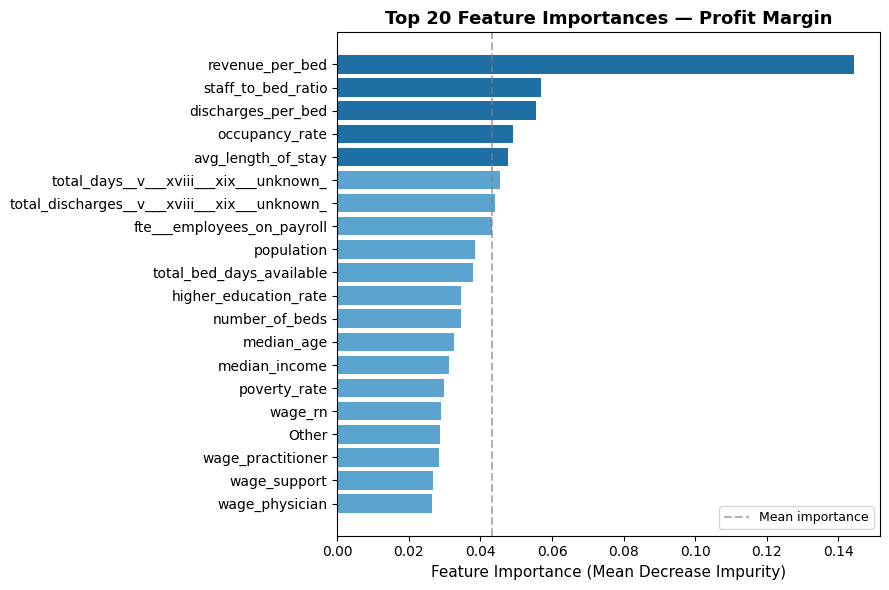

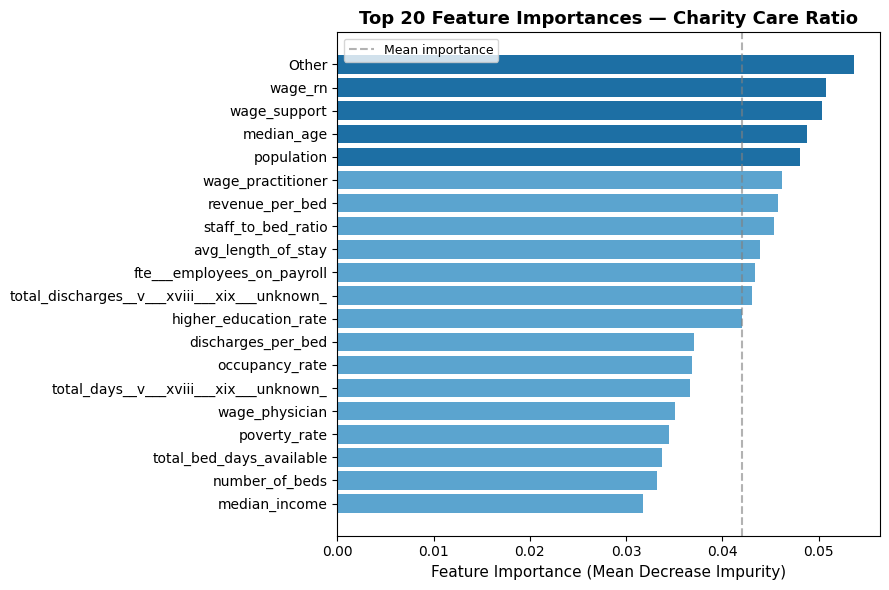

In [ ]:
def get_feature_names(pipeline):
    """Extract feature names after OHE transformation from a fitted pipeline."""
    preprocessor = pipeline.named_steps['preprocessor']
    ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    return NUMERICAL_FEATURES + cat_names


def plot_feature_importance(pipeline, title, top_n=20):
    """Plot top feature importances from a fitted pipeline."""
    feature_names = get_feature_names(pipeline)
    importances = pipeline.named_steps['model'].feature_importances_

    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    top = fi.head(top_n)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['#1D6FA4' if i < 5 else '#5BA4CF' for i in range(len(top))]
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax.set_xlabel('Feature Importance (Mean Decrease Impurity)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axvline(x=top.values.mean(), color='gray', linestyle='--', alpha=0.6, label='Mean importance')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    return fi

fi_pm  = plot_feature_importance(pipe_pm,  'Top 20 Feature Importances — Profit Margin')
fi_ccr = plot_feature_importance(pipe_ccr, 'Top 20 Feature Importances — Charity Care Ratio')

## 9. Actual vs Predicted Plots

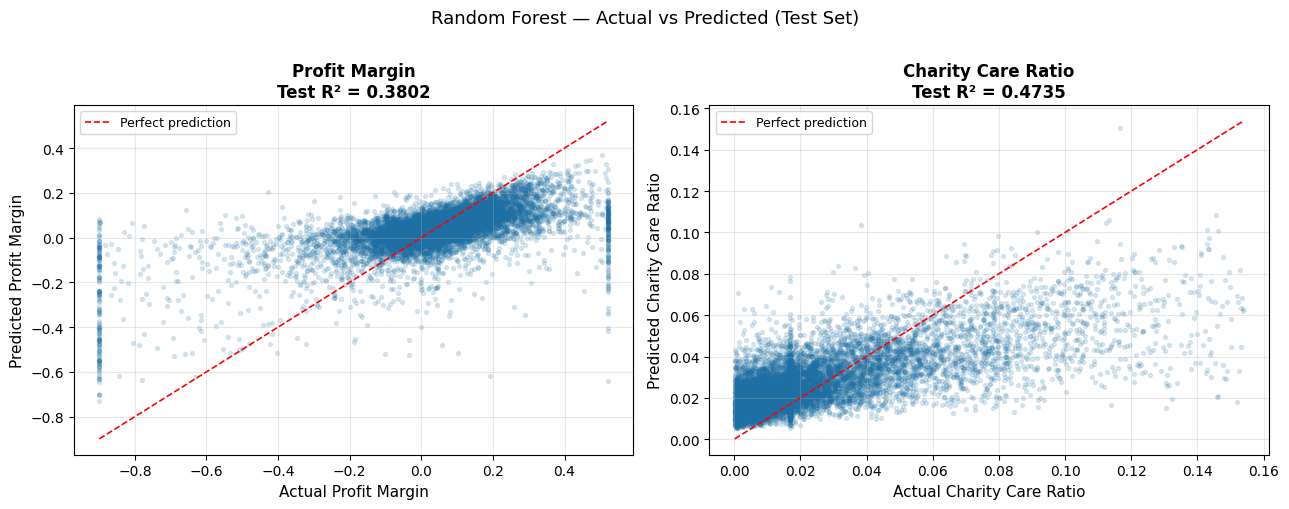

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title, r2 in [
    (axes[0], y_pm_test,  y_pm_pred_test,  'Profit Margin',      pm_test_r2),
    (axes[1], y_ccr_test, y_ccr_pred_test, 'Charity Care Ratio', ccr_test_r2),
]:
    # Clip extreme outliers for readability
    lo, hi = np.percentile(y_true, 1), np.percentile(y_true, 99)
    mask = (y_true >= lo) & (y_true <= hi)

    ax.scatter(y_true[mask], y_pred[mask], alpha=0.15, s=8,
               color='#1D6FA4', rasterized=True)

    # Perfect prediction line
    lims = [min(y_true[mask].min(), y_pred[mask].min()),
            max(y_true[mask].max(), y_pred[mask].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')

    ax.set_xlabel(f'Actual {title}', fontsize=11)
    ax.set_ylabel(f'Predicted {title}', fontsize=11)
    ax.set_title(f'{title}\nTest R² = {r2:.4f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Random Forest — Actual vs Predicted (Test Set)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Residual Analysis

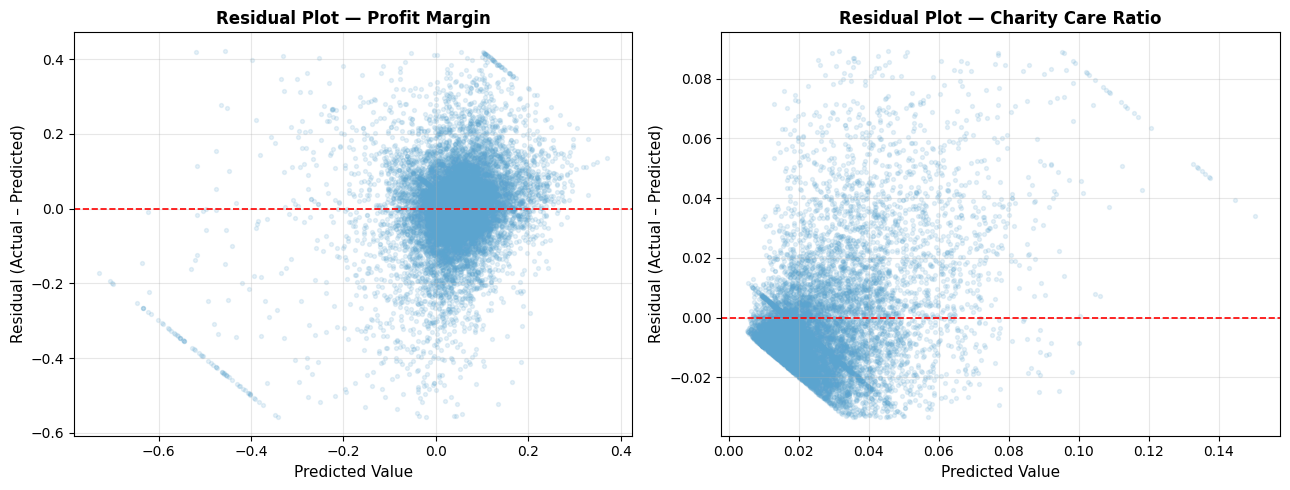

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_pm_test,  y_pm_pred_test,  'Profit Margin'),
    (axes[1], y_ccr_test, y_ccr_pred_test, 'Charity Care Ratio'),
]:
    residuals = y_true - y_pred
    lo, hi = np.percentile(residuals, 1), np.percentile(residuals, 99)
    mask = (residuals >= lo) & (residuals <= hi)

    ax.scatter(y_pred[mask], residuals[mask], alpha=0.15, s=8,
               color='#5BA4CF', rasterized=True)
    ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Predicted Value', fontsize=11)
    ax.set_ylabel('Residual (Actual – Predicted)', fontsize=11)
    ax.set_title(f'Residual Plot — {title}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Save Models

Both pipelines (preprocessor + model) are saved as `.pkl` files. Loading the pipeline automatically applies the same preprocessing to new data.

In [20]:
import os

# Update this path to your preferred output directory
OUTPUT_DIR = r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\Final Models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(pipe_pm,  os.path.join(OUTPUT_DIR, 'final_rf_profit_margin.pkl'))
joblib.dump(pipe_ccr, os.path.join(OUTPUT_DIR, 'final_rf_charity_care_ratio.pkl'))

print("Models saved:")
print(f"  {OUTPUT_DIR}\\final_rf_profit_margin.pkl")
print(f"  {OUTPUT_DIR}\\final_rf_charity_care_ratio.pkl")

Models saved:
  C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\Final Models\final_rf_profit_margin.pkl
  C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\Final Models\final_rf_charity_care_ratio.pkl


## 12. Using the Saved Models for Prediction

In [ ]:

# 1. Load the pipeline
#    loaded_pm  = joblib.load('final_rf_profit_margin.pkl')
#    loaded_ccr = joblib.load('final_rf_charity_care_ratio.pkl')
#
# 2. Prepare new data — must contain the same columns as ALL_FEATURES
#    new_data = pd.DataFrame({ ... })
#    new_data = new_data[ALL_FEATURES]   # ensure correct column order
#
# 3. Predict
#    pm_predictions  = loaded_pm.predict(new_data)
#    ccr_predictions = loaded_ccr.predict(new_data)
#
# The pipeline handles all imputation and encoding automatically.
# You do NOT need to preprocess new data manually.

# Quick demonstration using the test set
loaded_pm  = joblib.load(os.path.join(OUTPUT_DIR, 'final_rf_profit_margin.pkl'))
loaded_ccr = joblib.load(os.path.join(OUTPUT_DIR, 'final_rf_charity_care_ratio.pkl'))

sample = X_test.head(5).copy()
print("Sample predictions on 5 test hospitals:")
print(pd.DataFrame({
    'Actual Profit Margin':      y_pm_test.head(5).values.round(4),
    'Predicted Profit Margin':   loaded_pm.predict(sample).round(4),
    'Actual Charity Care Ratio': y_ccr_test.head(5).values.round(4),
    'Predicted Charity Care':    loaded_ccr.predict(sample).round(4)
}))

Sample predictions on 5 test hospitals:
   Actual Profit Margin  Predicted Profit Margin  Actual Charity Care Ratio  \
0               -0.1568                   0.0688                     0.0147   
1               -0.4926                   0.0565                     0.0090   
2               -0.0332                   0.0363                     0.0028   
3                0.1262                   0.0220                     0.0166   
4                0.0817                   0.0607                     0.0209   

   Predicted Charity Care  
0                  0.0293  
1                  0.0147  
2                  0.0246  
3                  0.0352  
4                  0.0184  


## Model Specifications Summary

| Feature | Profit Margin Model | Charity Care Ratio (CCR) Model |
| :--- | :--- | :--- |
| **Algorithm** | Random Forest (500 Trees) | Random Forest (500 Trees) |
| **Feature Set** | 27 Structured Predictors | 27 Structured Predictors |
| **Data Integrity** | Leakage Removed (Financial totals excluded) | Leakage Removed (Direct cost/ratio metrics excluded) |
| **Pipeline** | Median Imputation + One-Hot Encoding | Median Imputation + One-Hot Encoding |
| **Validation** | 5-Fold Cross-Validation | 5-Fold Cross-Validation |

### Strategic Interpretation

* **Profit Margin (Moderate Variance):**
    Predicting profitability remains challenging as it is heavily influenced by non-observable factors such as internal management efficiency, local market negotiations, and discretionary spending. The model captures the structural baseline but acknowledges the noise inherent in financial outcomes.

* **Charity Care Ratio (High Reliability):**
    CCR shows stronger predictive performance. This metric is more closely aligned with external structural drivers present in the data, including geographic rurality, community poverty levels, and institutional mission type (e.g., non-profit vs. for-profit status).

In [ ]:
import os
import joblib
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error

# Configuration
OUTPUT_DIR = r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\Final Models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Shared Preprocessor
def get_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", SimpleImputer(strategy="median"), NUMERICAL_FEATURES),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), CATEGORICAL_FEATURES),
    ])

# Training Function
def evaluate_model(name, model_obj, X_train, y_train, X_test, y_test, kf):
    """Fits model, calculates test metrics, and runs cross-validation."""
    pipe = Pipeline([("pre", get_preprocessor()), ("model", model_obj)])
    
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    
    preds = pipe.predict(X_test)
    test_r2 = r2_score(y_test, preds)
    test_mae = mean_absolute_error(y_test, preds)
    
    print(f"Running CV for {name}...")
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    
    return pipe, {
        "CV_R2_Mean": cv_scores.mean(),
        "CV_R2_Std": cv_scores.std(),
        "Test_R2": test_r2,
        "MAE": test_mae
    }

# Hyperparameters
xgb_params = dict(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, 
                  colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1)

lgbm_params = dict(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=40, 
                   subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1)

# Execution
results = []
models_to_save = {}

targets = [
    ("Profit Margin", y_pm_train, y_pm_test, "pm"),
    ("Charity Care", y_ccr_train, y_ccr_test, "ccr")
]

algorithms = [
    ("XGBoost", XGBRegressor(**xgb_params)),
    ("LightGBM", LGBMRegressor(**lgbm_params))
]

for target_name, y_tr, y_te, suffix in targets:
    for algo_name, algo_obj in algorithms:
        full_name = f"{algo_name} ({target_name})"
        pipe, metrics = evaluate_model(full_name, algo_obj, X_train, y_tr, X_test, y_te, kf)
        
        # Save results for table
        results.append({
            "Target": target_name,
            "Model": algo_name,
            **metrics
        })
        
        # Store pipe for saving
        models_to_save[f"{algo_name.lower()}_{suffix}.pkl"] = pipe

# Comparison & Display
df_res = pd.DataFrame(results)
print("\n" + "="*50 + "\n MODEL COMPARISON \n" + "="*50)
print(df_res.to_string(index=False))

# Save Models
for filename, pipe in models_to_save.items():
    joblib.dump(pipe, os.path.join(OUTPUT_DIR, filename))

print(f"\nSaved {len(models_to_save)} models to: {OUTPUT_DIR}")

Training XGBoost — Profit Margin ...
Training XGBoost — Charity Care Ratio ...
Running 5-fold CV — XGBoost Profit Margin ...
Running 5-fold CV — XGBoost Charity Care ...

── XGBoost Results ──────────────────────────────
  Profit Margin  | Test R²: 0.3348 | CV R²: 0.3336 ± 0.0127 | MAE: 0.0943
  Charity Care   | Test R²: 0.4102 | CV R²: 0.3981 ± 0.0080 | MAE: 0.0134

Training LightGBM — Profit Margin ...
Training LightGBM — Charity Care Ratio ...
Running 5-fold CV — LightGBM Profit Margin ...
Running 5-fold CV — LightGBM Charity Care ...

── LightGBM Results ─────────────────────────────
  Profit Margin  | Test R²: 0.3514 | CV R²: 0.3454 ± 0.0121 | MAE: 0.0928
  Charity Care   | Test R²: 0.4372 | CV R²: 0.4169 ± 0.0071 | MAE: 0.0131


══════════════════════════════════════════════════
  COMPLETE MODEL COMPARISON (CV R² = honest score)
══════════════════════════════════════════════════
                     Model  PM CV R²  PM Test R²  CCR CV R²  CCR Test R²
   Random Forest (current)   